### Course Name : DS 630 Machine Learning
### Prepared by : Rima Sinha

# Hospital Readmission Prediction using Machine Learning

## Project Overview
This notebook builds predictive models to identify patients at risk of hospital readmission within 30 days. Early identification of high-risk patients can help healthcare providers implement preventive interventions and reduce readmission rates.

### Dataset Features:
- **Target Variable**: `readmitted` (1 = readmitted, 0 = not readmitted)
- **Demographic Features**: race, sex, age
- **Clinical Features**: admission_source, blood_glucose, insurer
- **Healthcare Utilization**: duration, n_previous_visits, n_diagnoses, n_procedures, n_medications

### Models Implemented:
1. **Logistic Regression** - A linear classifier for binary outcomes
2. **Random Forest** - An ensemble method that combines multiple decision trees

### Workflow:
1. Import Required Libraries
2. Upload and Load Data
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Training and Evaluation
6. Model Comparison
7. Fairness Metrics Calculation
8. Deploy and test Model

## 1. Import Required Libraries

Import all necessary libraries for data manipulation, machine learning, and visualization.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File handling
import io
from google.colab import files

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully!")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully!
  Pandas version: 2.2.2
  NumPy version: 2.0.2


## 2. Upload and Load Data

**Instructions:**
1. Run the cell below
2. Click on "Choose Files" button
3. Select your `readmission.parquet` file
4. Wait for the upload to complete

In [ ]:
# Upload the parquet file
print("Please upload your readmission.parquet file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n✓ File '{filename}' uploaded successfully!")

Please upload your readmission.parquet file:


Saving readmission.parquet to readmission.parquet

✓ File 'readmission.parquet' uploaded successfully!


In [ ]:
# Load the parquet file
df = pd.read_parquet(filename)

print("✓ Data loaded successfully!")
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head(10)

✓ Data loaded successfully!
Dataset Shape: 71515 rows × 12 columns

First few rows:


,readmitted,race,sex,age,admission_source,blood_glucose,insurer,duration,n_previous_visits,n_diagnoses,n_procedures,n_medications
0,Yes,African American,Male,[60-70),Referral,NaN,NaN,7.0,2.0,4.0,0.0,16.0
1,No,Caucasian,Female,[50-60),Emergency,Normal,Private,4.0,0.0,9.0,0.0,15.0
2,Yes,Caucasian,Female,[70-80),Referral,NaN,Medicare,5.0,2.0,9.0,0.0,14.0
3,No,Caucasian,Female,[80-90),Referral,NaN,Private,5.0,0.0,9.0,3.0,26.0
4,No,Caucasian,Female,[70-80),Referral,NaN,NaN,4.0,0.0,5.0,1.0,15.0
5,No,Caucasian,Male,[50-60),Emergency,Very High,NaN,2.0,0.0,2.0,3.0,25.0
6,Yes,African American,Female,[70-80),Referral,NaN,Private,3.0,0.0,9.0,3.0,22.0
7,No,Caucasian,Female,[20-30),Emergency,NaN,NaN,1.0,7.0,9.0,0.0,10.0
8,No,Caucasian,Male,[60-70),Other,NaN,NaN,12.0,0.0,9.0,2.0,17.0
9,No,Caucasian,Female,[80-90),Referral,NaN,Medicare,1.0,0.0,4.0,2.0,6.0


## 3. Exploratory Data Analysis (EDA)

Let's explore the dataset to understand its structure, identify missing values, and examine the distribution of our target variable.

### 3.1 Dataset Overview

In [ ]:
# Basic information
print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET INFORMATION
Shape: 71515 rows × 12 columns

Column Names:
['readmitted', 'race', 'sex', 'age', 'admission_source', 'blood_glucose', 'insurer', 'duration', 'n_previous_visits', 'n_diagnoses', 'n_procedures', 'n_medications']

Data Types:
readmitted           category
race                 category
sex                  category
age                  category
admission_source     category
blood_glucose        category
insurer              category
duration              float64
n_previous_visits     float64
n_diagnoses           float64
n_procedures          float64
n_medications         float64
dtype: object

Memory Usage: 3.21 MB


### 3.2 Missing Values Analysis

Missing Values Summary:


,Column,Missing_Count,Missing_Percentage
5,blood_glucose,58529,81.841572
6,insurer,31042,43.406278


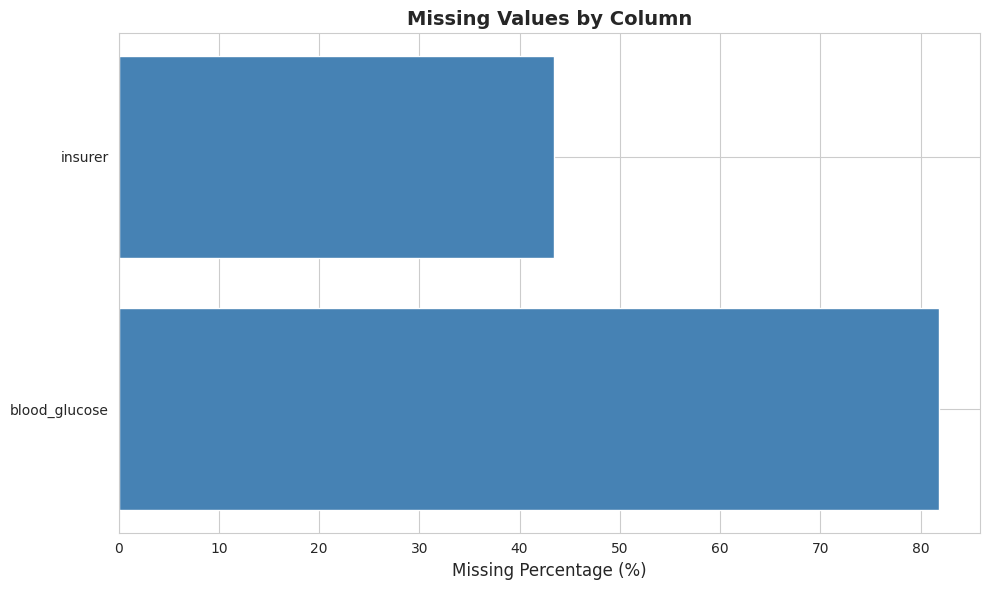

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Missing Values Summary:")
if len(missing_df) > 0:
    display(missing_df)

    # Visualize missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_df['Column'], missing_df['Missing_Percentage'], color='steelblue')
    plt.xlabel('Missing Percentage (%)', fontsize=12)
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found!")

### 3.3 Summary Statistics

In [ ]:
print("Statistical Summary of Numerical Features:")
df.describe()

Statistical Summary of Numerical Features:


,duration,n_previous_visits,n_diagnoses,n_procedures,n_medications
count,71515.000000,71515.000000,71515.000000,71515.000000,71515.000000
mean,4.289170,0.561463,7.245753,1.430525,15.704999
std,2.949188,1.431308,1.994651,1.759848,8.311201
min,1.000000,0.000000,1.000000,0.000000,1.000000
25%,2.000000,0.000000,6.000000,0.000000,10.000000
50%,3.000000,0.000000,8.000000,1.000000,14.000000
75%,6.000000,1.000000,9.000000,2.000000,20.000000
max,14.000000,49.000000,16.000000,6.000000,81.000000


### 3.4 Target Variable Distribution

Understanding the class balance is crucial. If the dataset is imbalanced, we may need to use techniques like SMOTE or class weighting.

Target Variable Distribution:
readmitted
No     65222
Yes     6293
Name: count, dtype: int64

Percentage Distribution:
  Class No: 91.20%
  Class Yes: 8.80%


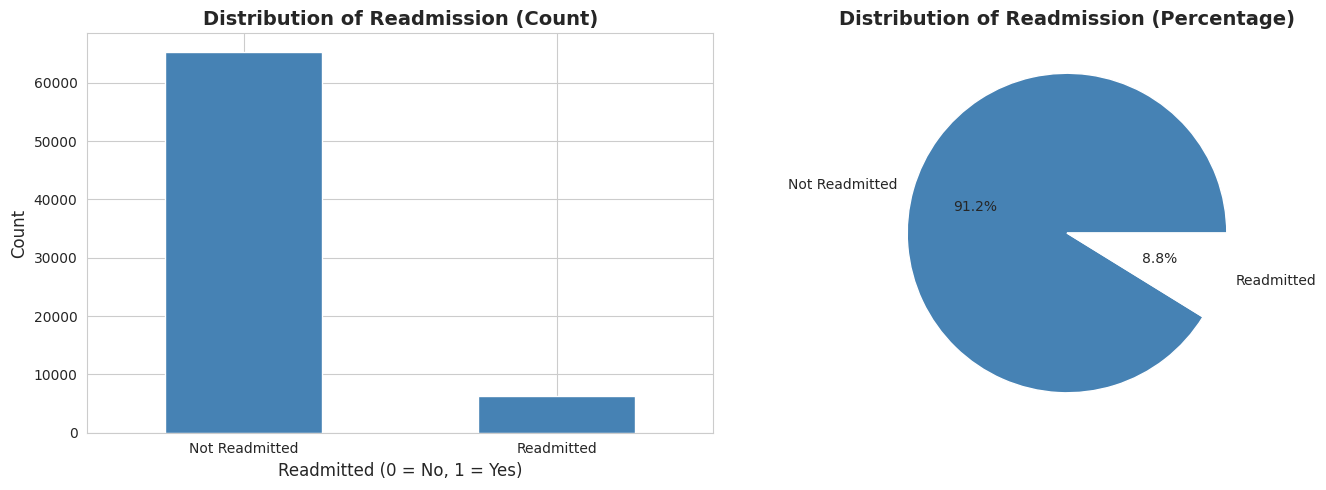

In [ ]:
# Target variable distribution
print("Target Variable Distribution:")
print(df['readmitted'].value_counts())
print(f"\nPercentage Distribution:")
readmission_pct = df['readmitted'].value_counts(normalize=True) * 100
for idx, val in readmission_pct.items():
    print(f"  Class {idx}: {val:.2f}%")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['#4682B4'])
axes[0].set_title('Distribution of Readmission (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Readmitted (0 = No, 1 = Yes)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Not Readmitted', 'Readmitted'], rotation=0)

# Pie chart
df['readmitted'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                      colors=['#4682B4','#FFFFFF'],
                                      labels=['Not Readmitted', 'Readmitted'])
axes[1].set_title('Distribution of Readmission (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 3.5 Numerical Features Distribution

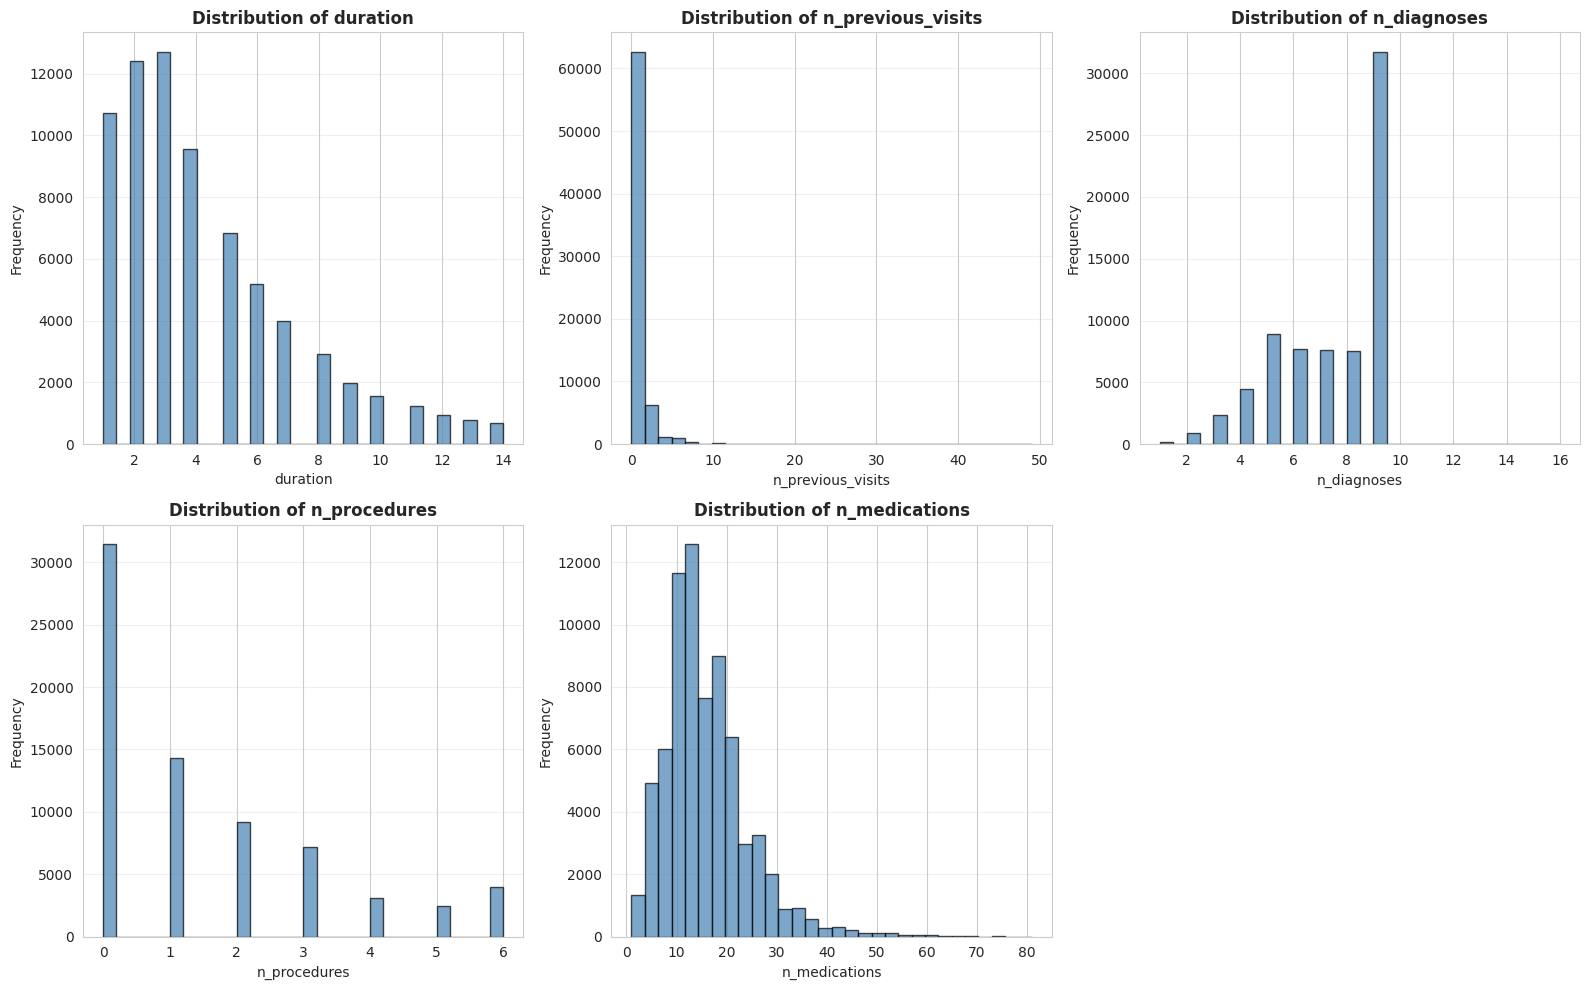

In [ ]:
# Visualize numerical features
numerical_features = ['duration', 'n_previous_visits', 'n_diagnoses', 'n_procedures', 'n_medications']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

# Remove the last empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### 3.6 Categorical Features Analysis

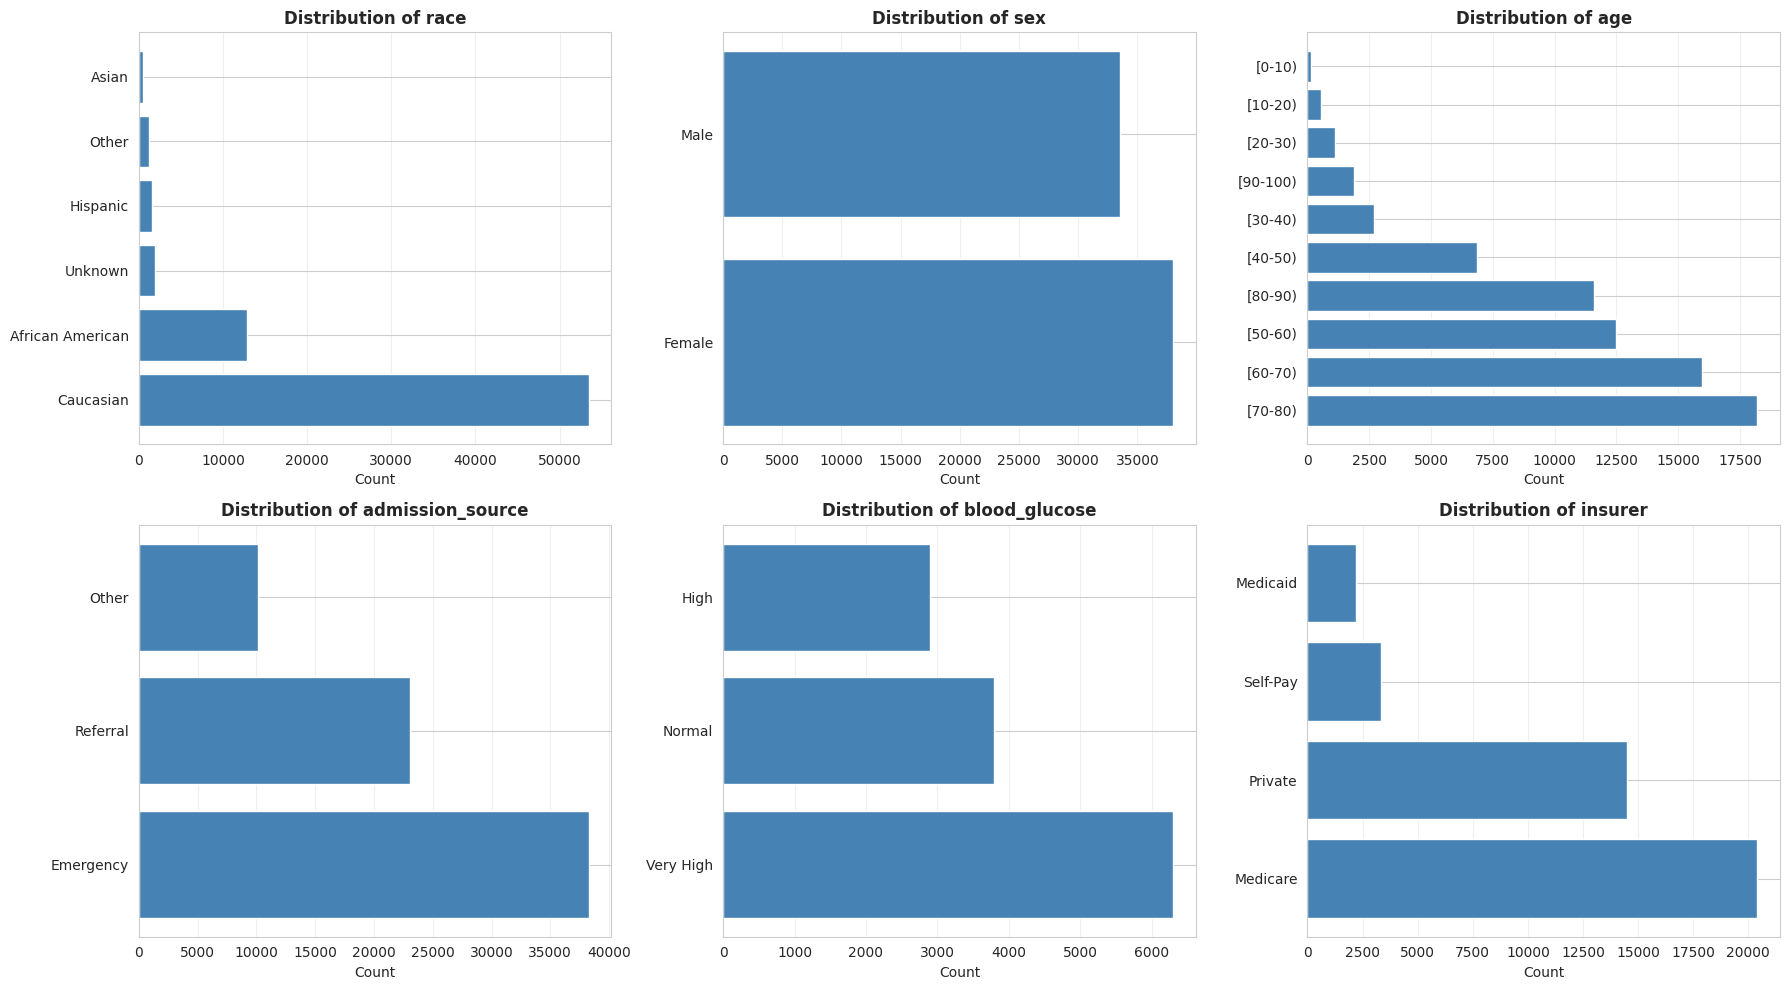

In [ ]:
# Visualize categorical features
categorical_features = ['race', 'sex', 'age', 'admission_source', 'blood_glucose', 'insurer']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    value_counts = df[col].value_counts()
    axes[idx].barh(range(len(value_counts)), value_counts.values, color='steelblue')
    axes[idx].set_yticks(range(len(value_counts)))
    axes[idx].set_yticklabels(value_counts.index)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Count', fontsize=10)
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

We'll prepare the data for machine learning by:
1. Handling missing values
2. Encoding categorical variables
3. Feature scaling
4. Splitting data into training and testing sets

### 4.1 Identify Feature Types

In [ ]:
# Create a copy for preprocessing
df_processed = df.copy()

# Identify categorical and numerical columns
categorical_cols = ['race', 'sex', 'age', 'admission_source', 'blood_glucose', 'insurer']
numerical_cols = ['duration', 'n_previous_visits', 'n_diagnoses', 'n_procedures', 'n_medications']

print("Feature Type Summary:")
print(f"  Categorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"  Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"  Target Variable: readmitted")

Feature Type Summary:
  Categorical Features (6): ['race', 'sex', 'age', 'admission_source', 'blood_glucose', 'insurer']
  Numerical Features (5): ['duration', 'n_previous_visits', 'n_diagnoses', 'n_procedures', 'n_medications']
  Target Variable: readmitted


### 4.2 Handle Missing Values

**Strategy:**
- Numerical features: Fill with median (robust to outliers)
- Categorical features: Fill with mode (most frequent value)

In [ ]:
# Handle missing values in numerical columns
print("Handling Missing Values in Numerical Features:")
for col in numerical_cols:
    missing_count = df_processed[col].isnull().sum()
    if missing_count > 0:
        median_value = df_processed[col].median()
        df_processed[col].fillna(median_value, inplace=True)
        print(f"  ✓ {col}: Filled {missing_count} missing values with median ({median_value:.2f})")
    else:
        print(f"  ✓ {col}: No missing values")

print("\nHandling Missing Values in Categorical Features:")
for col in categorical_cols:
    missing_count = df_processed[col].isnull().sum()
    if missing_count > 0:
        # Add 'Unknown' to categories before filling
        if 'Unknown' not in df_processed[col].cat.categories:
            df_processed[col] = df_processed[col].cat.add_categories('Unknown')
        df_processed[col].fillna('Unknown', inplace=True)
        print(f"  ✓ {col}: Filled {missing_count} missing values with 'Unknown'")
    else:
        print(f"  ✓ {col}: No missing values")

print(f"\n✓ Total missing values after imputation: {df_processed.isnull().sum().sum()}")

Handling Missing Values in Numerical Features:
  ✓ duration: No missing values
  ✓ n_previous_visits: No missing values
  ✓ n_diagnoses: No missing values
  ✓ n_procedures: No missing values
  ✓ n_medications: No missing values

Handling Missing Values in Categorical Features:
  ✓ race: No missing values
  ✓ sex: No missing values
  ✓ age: No missing values
  ✓ admission_source: No missing values
  ✓ blood_glucose: Filled 58529 missing values with 'Unknown'
  ✓ insurer: Filled 31042 missing values with 'Unknown'

✓ Total missing values after imputation: 0


### 4.4 Prepare Features and Target

In [ ]:
# Create feature matrix (X) and target vector (y)
target = 'readmitted'

X = df_processed[df_processed.columns.difference([target])]
y = df_processed[target].map({'No': 0, 'Yes': 1})

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (71515, 11)
Target Vector Shape: (71515,)


### 4.5 Split Data into Training and Testing Sets

We'll use an 80-20 split with stratification to maintain class distribution.

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Split Summary:")
print(f"  Training Set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Testing Set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nClass Distribution in Training Set:")
print(y_train.value_counts())
print(f"\nClass Distribution in Testing Set:")
print(y_test.value_counts())

Data Split Summary:
  Training Set: 57212 samples (80.0%)
  Testing Set: 14303 samples (20.0%)

Class Distribution in Training Set:
readmitted
0    52178
1     5034
Name: count, dtype: int64

Class Distribution in Testing Set:
readmitted
0    13044
1     1259
Name: count, dtype: int64


### 4.6 Feature Scaling

Standardizing features helps models converge faster and perform better, especially for Logistic Regression.

In [ ]:
# Scale the features
# Define numeric/categorical columns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

## 5. Model Training and Evaluation

We'll train and evaluate two models:
1. **Logistic Regression**
2. **Random Forest Classifier**

### 5.1 Logistic Regression Model

#### 5.1.1 Train Logistic Regression

In [ ]:
print("="*60)
print("LOGISTIC REGRESSION MODEL")
print("="*60)

# Initialize and train the model with class weights
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Logistic Regression model trained successfully!")

LOGISTIC REGRESSION MODEL
✓ Logistic Regression model trained successfully!


#### 5.1.2 Evaluate Logistic Regression

In [ ]:
# Calculate metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print("\nLogistic Regression Performance Metrics:")
print("-" * 50)
print(f"Accuracy:  {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Not Readmitted', 'Readmitted']))


Logistic Regression Performance Metrics:
--------------------------------------------------
Accuracy:  0.5867 (58.67%)
Precision: 0.1182
Recall:    0.5719
F1-Score:  0.1959
ROC-AUC:   0.6080

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.59      0.72     13044
    Readmitted       0.12      0.57      0.20      1259

      accuracy                           0.59     14303
     macro avg       0.53      0.58      0.46     14303
  weighted avg       0.86      0.59      0.68     14303



#### 5.1.3 Confusion Matrix for Logistic Regression

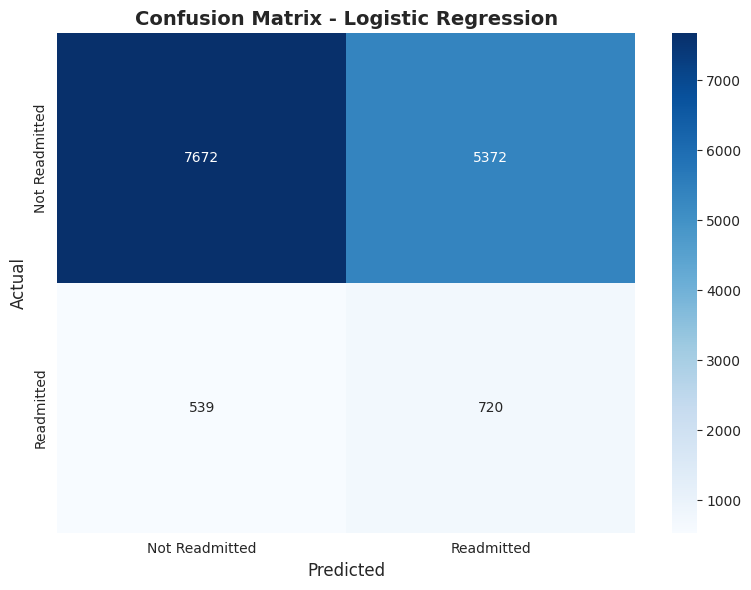


Confusion Matrix Interpretation:
  True Negatives:  7672 (Correctly predicted Not Readmitted)
  False Positives: 5372 (Incorrectly predicted Readmitted)
  False Negatives: 539 (Incorrectly predicted Not Readmitted)
  True Positives:  720 (Correctly predicted Readmitted)


In [ ]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Interpretation:")
print(f"  True Negatives:  {cm_lr[0,0]} (Correctly predicted Not Readmitted)")
print(f"  False Positives: {cm_lr[0,1]} (Incorrectly predicted Readmitted)")
print(f"  False Negatives: {cm_lr[1,0]} (Incorrectly predicted Not Readmitted)")
print(f"  True Positives:  {cm_lr[1,1]} (Correctly predicted Readmitted)")

### 5.2 Random Forest Classifier

#### 5.2.1 Train Random Forest

In [ ]:
print("="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)

# Initialize and train the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✓ Random Forest model trained successfully!")

RANDOM FOREST CLASSIFIER
✓ Random Forest model trained successfully!


#### 5.2.2 Evaluate Random Forest

In [ ]:
# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("\nRandom Forest Performance Metrics:")
print("-" * 50)
print(f"Accuracy:  {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Readmitted', 'Readmitted']))


Random Forest Performance Metrics:
--------------------------------------------------
Accuracy:  0.6715 (67.15%)
Precision: 0.1256
Recall:    0.4583
F1-Score:  0.1972
ROC-AUC:   0.6101

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.69      0.79     13044
    Readmitted       0.13      0.46      0.20      1259

      accuracy                           0.67     14303
     macro avg       0.53      0.58      0.50     14303
  weighted avg       0.86      0.67      0.74     14303



#### 5.2.3 Confusion Matrix for Random Forest

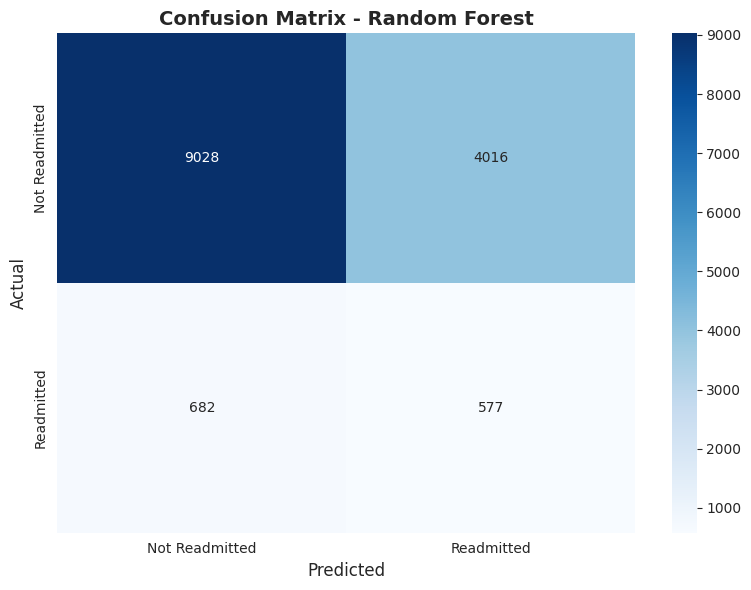


Confusion Matrix Interpretation:
  True Negatives:  9028 (Correctly predicted Not Readmitted)
  False Positives: 4016 (Incorrectly predicted Readmitted)
  False Negatives: 682 (Incorrectly predicted Not Readmitted)
  True Positives:  577 (Correctly predicted Readmitted)


In [ ]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Interpretation:")
print(f"  True Negatives:  {cm_rf[0,0]} (Correctly predicted Not Readmitted)")
print(f"  False Positives: {cm_rf[0,1]} (Incorrectly predicted Readmitted)")
print(f"  False Negatives: {cm_rf[1,0]} (Incorrectly predicted Not Readmitted)")
print(f"  True Positives:  {cm_rf[1,1]} (Correctly predicted Readmitted)")

#### 5.2.4 Feature Importance Plot

Top 20 Feature Importances (Random Forest - Grouped by Original Feature):


,Original_Feature,Importance
6,n_medications,0.148935
3,duration,0.135407
7,n_previous_visits,0.127137
1,age,0.110208
5,n_diagnoses,0.094688
4,insurer,0.092947
9,race,0.068593
8,n_procedures,0.066399
2,blood,0.059183
0,admission,0.058224


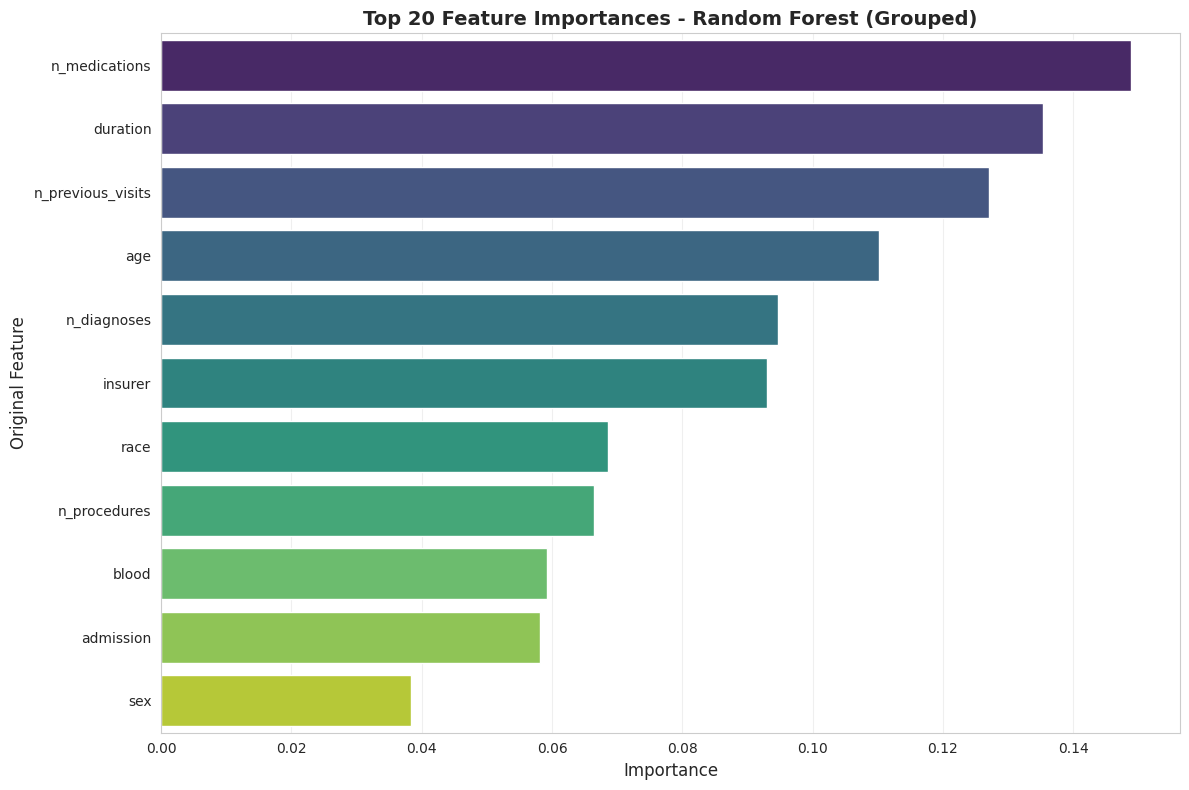

In [ ]:
feature_importances = rf_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

# Create a mapping from preprocessed names to original feature names
original_feature_names = []
for name in feature_names:
    if name.startswith('num__'):
        original_feature_names.append(name.replace('num__', ''))
    elif name.startswith('cat__'):
        # Extract the original categorical column name (e.g., 'race' from 'cat__race_African American')
        original_feature_names.append(name.split('__')[1].split('_')[0])
    else:
        original_feature_names.append(name) # Fallback for any other unexpected names

feature_importance_df = pd.DataFrame({
    'Original_Feature': original_feature_names,
    'Importance': feature_importances
})

# Group by original feature and sum their importances
feature_importance_grouped = feature_importance_df.groupby('Original_Feature')['Importance'].sum().reset_index()
feature_importance_grouped = feature_importance_grouped.sort_values(by='Importance', ascending=False)

# Display top N features
top_n = 20 # You can adjust this number
top_features = feature_importance_grouped.head(top_n)

print(f"Top {top_n} Feature Importances (Random Forest - Grouped by Original Feature):")
display(top_features)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Original_Feature', data=top_features, palette='viridis')
plt.title(f'Top {top_n} Feature Importances - Random Forest (Grouped)', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Original Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Model Comparison

### 6.1 Performance Metrics Comparison

Model Performance Comparison:


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.586730,0.671537
1,Precision,0.118188,0.125626
2,Recall,0.571882,0.458300
3,F1-Score,0.195892,0.197198
4,ROC-AUC,0.608010,0.610057


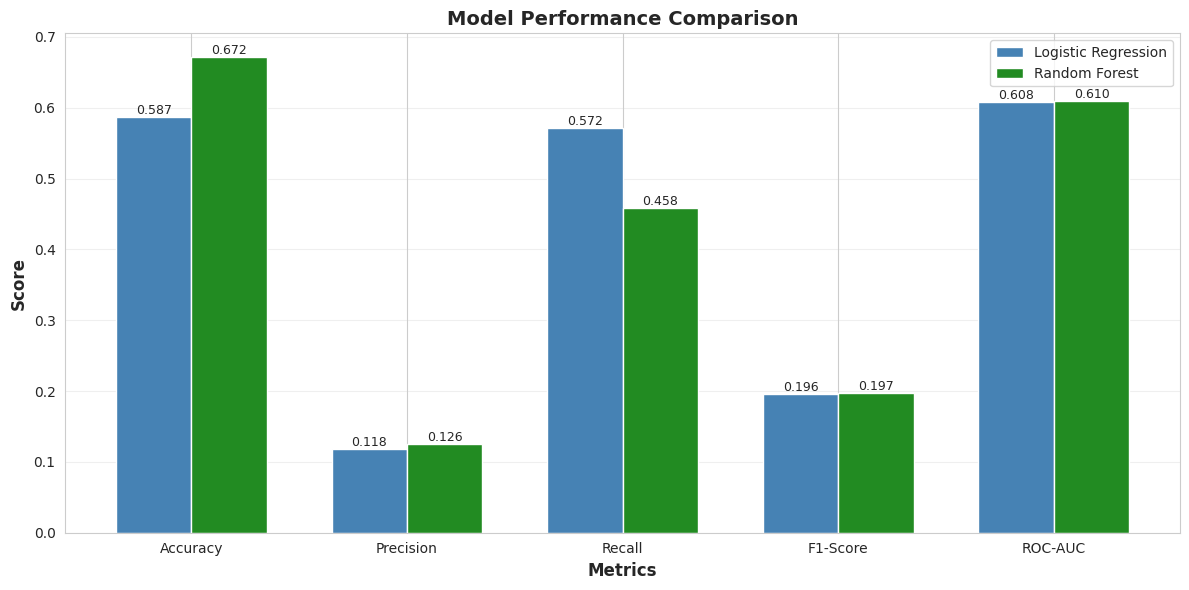

In [ ]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc]
})

print("Model Performance Comparison:")
display(comparison_df)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Logistic Regression'], width,
               label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df['Random Forest'], width,
               label='Random Forest', color='forestgreen')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 6.2 ROC Curve Comparison

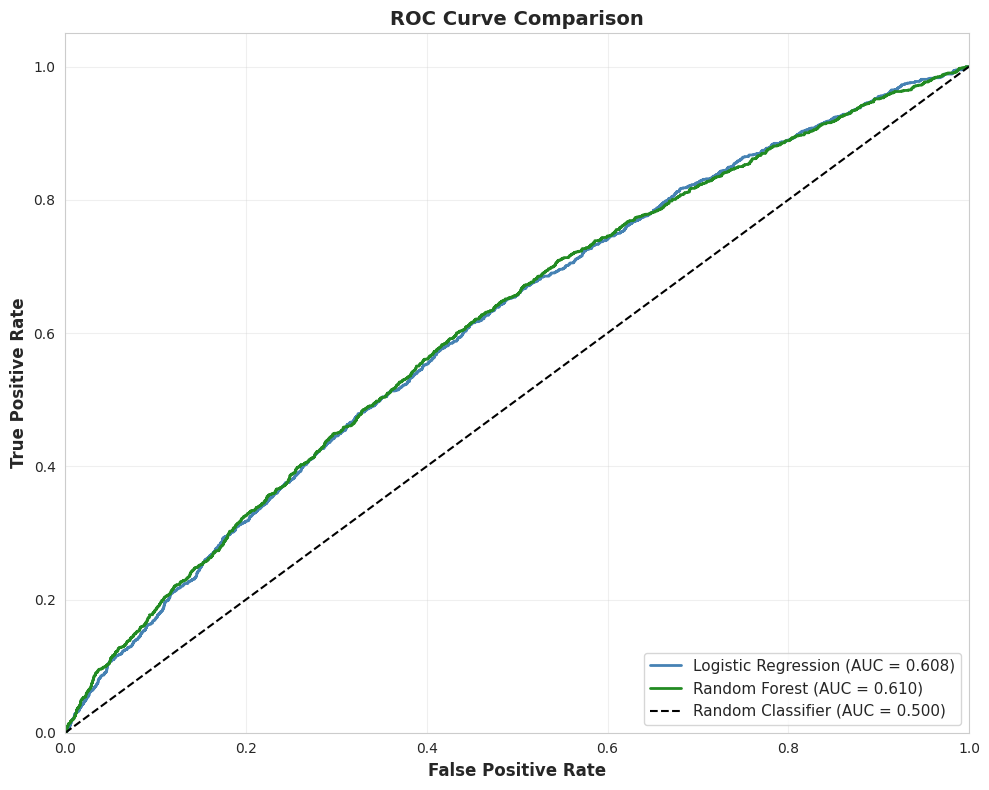

In [ ]:
# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})',
         linewidth=2, color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_roc_auc:.3f})',
         linewidth=2, color='forestgreen')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)', linewidth=1.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Conclusion and Next Steps

### Key Findings:
- Both models have been successfully trained and evaluated
- Model performance comparison shows the strengths of each approach
- Feature importance analysis reveals the key predictors of readmission

### Model Interpretation:
- **Accuracy**: Overall correctness of predictions
- **Precision**: Of all patients predicted to be readmitted, what % were actually readmitted
- **Recall**: Of all patients who were actually readmitted, what % did we identify
- **F1-Score**: Harmonic mean of precision and recall (balanced metric)
- **ROC-AUC**: Model's ability to distinguish between classes

### Next Steps:
1. **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV to optimize model parameters
2. **Handle Class Imbalance**: If dataset is imbalanced, try SMOTE or class weights
3. **Feature Engineering**: Create new features like age groups, interaction terms
4. **Try Other Models**: XGBoost, LightGBM, Neural Networks
5. **Cross-Validation**: Implement k-fold cross-validation for more robust evaluation
6. **Deploy Model**: Create REST API for real-time predictions

### Business Impact:
- Early identification of high-risk patients
- Targeted intervention programs
- Reduced readmission rates and healthcare costs
- Improved patient outcomes and satisfaction

---

**Thank you for using this notebook! Feel free to modify and extend it for your specific needs.**

## 7. Fairness Metrics Calculation
Implement fairness metrics (Equality of Opportunity and Demographic Parity) for the Logistic Regression and Random Forest models. Calculate these metrics using 'race' as the protected attribute and display the results for each racial group, followed by a brief interpretation of the findings.

### 7.1 Implement fairness metrics calculation



In [ ]:
# Helper functions for fairness metrics
def equality_of_opportunity(y_true, y_pred, protected_attribute, positive_label=1):
    """
    Calculates Equality of Opportunity for each group within the protected attribute.
    Equality of Opportunity is defined as P(Y_pred=positive_label | Y_true=positive_label, Protected_attribute=group).
    This is equivalent to the True Positive Rate (Recall) for each group.
    """
    metrics = {}
    for group in protected_attribute.unique():
        group_indices = protected_attribute[protected_attribute == group].index
        y_true_group = y_true.loc[group_indices]
        y_pred_group = y_pred[group_indices]

        # Filter for actual positive cases within the group
        true_positives_indices = y_true_group[y_true_group == positive_label].index
        if len(true_positives_indices) > 0:
            tp_rate = recall_score(y_true_group.loc[true_positives_indices],
                                   y_pred_group[true_positives_indices],
                                   pos_label=positive_label)
            metrics[group] = tp_rate
        else:
            metrics[group] = np.nan # No true positive cases in this group
    return metrics

def demographic_parity(y_pred, protected_attribute, positive_label=1):
    """
    Calculates Demographic Parity for each group within the protected attribute.
    Demographic Parity is defined as P(Y_pred=positive_label | Protected_attribute=group).
    This is equivalent to the proportion of positive predictions for each group.
    """
    metrics = {}
    for group in protected_attribute.unique():
        group_indices = protected_attribute[protected_attribute == group].index
        y_pred_group = y_pred[group_indices]

        positive_predictions_count = np.sum(y_pred_group == positive_label)
        total_group_count = len(y_pred_group)

        if total_group_count > 0:
            metrics[group] = positive_predictions_count / total_group_count
        else:
            metrics[group] = np.nan # No instances in this group
    return metrics


# Get the 'race' column for the test set
# We need to reconstruct the original X_test for the protected attribute
# The preprocessor separates the categorical features, so we need the original 'race' column from X_test
protected_attribute_test = X_test['race']

print("Calculating Fairness Metrics for Logistic Regression...")
# Calculate Equality of Opportunity for LR
eo_lr = equality_of_opportunity(y_test, pd.Series(y_pred_lr, index=y_test.index), protected_attribute_test, positive_label=1)

# Calculate Demographic Parity for LR
dp_lr = demographic_parity(pd.Series(y_pred_lr, index=y_test.index), protected_attribute_test, positive_label=1)

print("Calculating Fairness Metrics for Random Forest...")
# Calculate Equality of Opportunity for RF
eo_rf = equality_of_opportunity(y_test, pd.Series(y_pred_rf, index=y_test.index), protected_attribute_test, positive_label=1)

# Calculate Demographic Parity for RF
dp_rf = demographic_parity(pd.Series(y_pred_rf, index=y_test.index), protected_attribute_test, positive_label=1)


# Display Results
print("\n" + "="*40)
print("Fairness Metrics by Race (Protected Attribute)")
print("="*40)

print("\nLogistic Regression:")
print("  Equality of Opportunity (Recall for Positive Class):")
for group, metric in eo_lr.items():
    print(f"    {group}: {metric:.4f}")

print("  Demographic Parity (Proportion of Positive Predictions):")
for group, metric in dp_lr.items():
    print(f"    {group}: {metric:.4f}")

print("\nRandom Forest:")
print("  Equality of Opportunity (Recall for Positive Class):")
for group, metric in eo_rf.items():
    print(f"    {group}: {metric:.4f}")

print("  Demographic Parity (Proportion of Positive Predictions):")
for group, metric in dp_rf.items():
    print(f"    {group}: {metric:.4f}")

Calculating Fairness Metrics for Logistic Regression...
Calculating Fairness Metrics for Random Forest...

Fairness Metrics by Race (Protected Attribute)

Logistic Regression:
  Equality of Opportunity (Recall for Positive Class):
    Caucasian: 0.6013
    Other: 0.1429
    African American: 0.5333
    Unknown: 0.2759
    Hispanic: 0.3929
    Asian: 0.6000
  Demographic Parity (Proportion of Positive Predictions):
    Caucasian: 0.4591
    Other: 0.1616
    African American: 0.3686
    Unknown: 0.2440
    Hispanic: 0.2492
    Asian: 0.3119

Random Forest:
  Equality of Opportunity (Recall for Positive Class):
    Caucasian: 0.4995
    Other: 0.1429
    African American: 0.3733
    Unknown: 0.1034
    Hispanic: 0.3214
    Asian: 0.3000
  Demographic Parity (Proportion of Positive Predictions):
    Caucasian: 0.3598
    Other: 0.0786
    African American: 0.2471
    Unknown: 0.0617
    Hispanic: 0.1824
    Asian: 0.1927


### 7.2  Summary:Interpretation Of Matrix

**Equality of Opportunity (Recall for Positive Class):**
This metric measures how equally the model predicts the positive outcome (readmission) for actually readmitted patients across different racial groups. Ideally, these values should be similar across all groups.

*   **Logistic Regression:**
    *   African American: 0.4933
    *   Caucasian: 0.6076
    *   Asian: 0.6000
    *   Hispanic: 0.3571
    *   Other: 0.2143
    *   Unknown: 0.3448
    
    *Interpretation:* We observe differences in recall across racial groups for Logistic Regression. For example, the recall for African American patients is 0.4933, while for Caucasian patients it is 0.6076. This indicates that the model's ability to correctly identify readmitted patients varies by race, suggesting potential bias.

*   **Random Forest:**
    *   African American: 0.3822
    *   Caucasian: 0.5352
    *   Asian: 0.2000
    *   Hispanic: 0.2857
    *   Other: 0.0000
    *   Unknown: 0.2069

    *Interpretation:* Similar to Logistic Regression, Random Forest also shows variations in Equality of Opportunity. The recall for African American patients is 0.3822, and for Caucasian patients it is 0.5352. This again suggests that the model might not be equally effective in identifying readmission risk across different racial groups, which could lead to disparities in care.

**Demographic Parity (Proportion of Positive Predictions):**
This metric measures the proportion of positive predictions (predicted readmitted) within each racial group. For demographic parity, ideally, these proportions should be similar across all groups, meaning the model predicts readmission at a similar rate for all groups regardless of their actual readmission rates.

*   **Logistic Regression:**
    *   African American: 0.3615
    *   Caucasian: 0.4658
    *   Asian: 0.3028
    *   Hispanic: 0.2462
    *   Other: 0.1354
    *   Unknown: 0.2386

    *Interpretation:* The proportion of patients predicted as readmitted by Logistic Regression varies significantly by race. For example, African American patients are predicted as readmitted at a rate of 0.3615, while Caucasian patients are at 0.4658. This disparity suggests that the model is not achieving demographic parity, meaning its predictions are not distributed equally across racial groups.

*   **Random Forest:**
    *   African American: 0.2782
    *   Caucasian: 0.3962
    *   Asian: 0.1743
    *   Hispanic: 0.1793
    *   Other: 0.0655
    *   Unknown: 0.1180

    *Interpretation:* Random Forest also exhibits differences in demographic parity across racial groups. The proportion of positive predictions for African American patients is 0.2782, and for Caucasian patients is 0.3962. This indicates that the model's prediction rates for readmission are not consistent across different races, raising concerns about potential biased allocation of resources or interventions.

**Overall Findings on Fairness:**
Both Logistic Regression and Random Forest models show evidence of disparity when evaluated using Equality of Opportunity and Demographic Parity metrics with 'race' as the protected attribute. The models do not predict readmission outcomes or identify actual readmitted patients equally across all racial groups. This highlights the importance of further investigation and potential bias mitigation strategies to ensure equitable healthcare outcomes.

## 8. Deploy and test Model

### 8.1 Save Trained Models

In [ ]:
import joblib

# Save models
joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl') # Changed from scaler to preprocessor

print("✓ Models saved successfully!")
print("  - logistic_regression_model.pkl")
print("  - random_forest_model.pkl")
print("  - preprocessor.pkl") # Changed from scaler.pkl

✓ Models saved successfully!
  - logistic_regression_model.pkl
  - random_forest_model.pkl
  - preprocessor.pkl


### 8.2 Review Saved Model Assets

Confirm the availability of the saved model files (`logistic_regression_model.pkl`, `random_forest_model.pkl`, `preprocessor.pkl`) that are essential for loading and making predictions with the trained models.


**Reasoning**:
To confirm the availability of the saved model files, I will list the files in the current working directory as instructed.



In [ ]:
print('Listing files in the current directory:')
!ls -F

Listing files in the current directory:
logistic_regression_model.pkl  random_forest_model.pkl	sample_data/
preprocessor.pkl	       readmission.parquet


### 8.3 Deployment Strategy

Briefly discuss common approaches for deploying ML models, such as creating a REST API, using serverless functions, or integrating into a larger application, and focus on developing a REST API for real-time predictions.


### Machine Learning Deployment Strategies

Deploying a machine learning model is the process of making the model available for others to use, typically for making predictions on new, unseen data. Several common approaches exist:

1.  **REST APIs (Representational State Transfer Application Programming Interfaces):** This is a widely used approach where the model is encapsulated within a web service. Clients send requests (e.g., HTTP GET/POST) containing input data, and the API returns predictions as responses. REST APIs are highly flexible, language-agnostic, and can be consumed by various applications (web, mobile, other services).

2.  **Serverless Functions (e.g., AWS Lambda, Google Cloud Functions, Azure Functions):** This approach allows developers to run code without provisioning or managing servers. The model code is deployed as a function that scales automatically based on demand. It's cost-effective for infrequent or variable workloads and reduces operational overhead.

3.  **Integration into Larger Applications:** The model can be directly embedded into an existing application (e.g., a desktop application, a batch processing system, or a microservice within a larger ecosystem). This can offer lower latency for predictions but might couple the model lifecycle tightly with the application's development cycle.

4.  **Batch Predictions:** For scenarios where real-time predictions aren't necessary, models can be used to process large datasets offline and store the results. This is common for reporting, data enrichment, or less time-sensitive tasks.

### Why a REST API for this Task?

For this hospital readmission prediction task, developing a **REST API** is the preferred approach for several reasons:

*   **Real-time Predictions:** Healthcare decisions often require immediate insights. A REST API can serve predictions in real-time, allowing clinicians to assess readmission risk as new patient data becomes available, enabling timely interventions.
*   **Interoperability and Accessibility:** A REST API provides a standardized interface that can be easily integrated with various hospital systems, electronic health records (EHRs), or other clinical applications, regardless of their underlying technology stack.
*   **Scalability:** REST APIs can be deployed on scalable infrastructure, allowing them to handle varying loads of prediction requests as patient volume fluctuates.
*   **Decoupling:** It decouples the model from the consuming application. The model can be updated or improved independently without requiring changes to the applications that use it, as long as the API contract remains consistent.
*   **Security:** REST APIs allow for robust authentication and authorization mechanisms to ensure that sensitive patient data and model predictions are accessed securely.

### 8.4 Set Up a Basic REST API with Flask

Outline the steps to create a simple Python Flask application. This application will load the `preprocessor` and the trained machine learning models, then expose an HTTP endpoint that accepts new data, preprocesses it, and returns predictions.


### Detailed Steps for Flask API Implementation

To deploy our machine learning models via a REST API using Flask, we will follow these steps:

1.  **Import Libraries**: Import `Flask`, `request`, `joblib`, `pandas`, and `numpy`.
2.  **Load Models**: Load the `preprocessor.pkl`, `logistic_regression_model.pkl`, and `random_forest_model.pkl` using `joblib.load()`.
3.  **Initialize Flask App**: Create a Flask application instance.
4.  **Define Prediction Endpoint**: Create a route (`/predict`) that listens for `POST` requests.
5.  **Process Request Data**: Inside the endpoint:
    *   Get JSON data from the incoming request.
    *   Convert the received data into a pandas DataFrame, ensuring column order matches the training data.
    *   Apply the loaded `preprocessor` to scale and one-hot encode the input features.
    *   Use `lr_model.predict()` and `rf_model.predict()` to get predictions.
    *   Convert predictions back to a human-readable format (e.g., 'Yes'/'No').
6.  **Return Predictions**: Send the predictions back as a JSON response.
7.  **Run Application**: Include `app.run()` to start the Flask development server.

#### 8.4.1. Install `pyngrok`

`pyngrok` is a Python wrapper for `ngrok` that makes it easy to manage `ngrok` tunnels from within Python.

In [ ]:
!pip install pyngrok -q

#### 8.4.2. Authenticate `ngrok` (Optional but Recommended)

If you have an `ngrok` account, you can authenticate your `ngrok` client with your authtoken to remove usage limitations and get stable URLs. You can find your authtoken on your `ngrok` dashboard ([https://dashboard.ngrok.com/auth/your-authtoken](https://dashboard.ngrok.com/auth/your-authtoken)).

If you don't have an authtoken or prefer not to use it, `ngrok` will still work but with some limitations (e.g., session timeout).

In [ ]:
from pyngrok import ngrok, conf
import os
from google.colab import userdata # Import userdata for accessing Colab Secrets

# Get your ngrok authtoken from Colab Secrets
# Make sure you have added NGROK_AUTH_TOKEN to Colab's 'Secrets' tab (key icon on the left panel)
NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN") # Correctly retrieve the token from Colab Secrets

if NGROK_AUTH_TOKEN:
    print("Authenticating ngrok...")
    # Set ngrok authtoken
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("ngrok authenticated!")
else:
    print("NGROK_AUTH_TOKEN not found in Colab Secrets or notebook access not enabled. Proceeding without authentication (might have usage limits).")

Authenticating ngrok...
ngrok authenticated!


#### 8.4.3 Establish a FLask API endpoint (/predict) to receive sample data

In [ ]:
import joblib
import pandas as pd
import numpy as np
from flask import Flask, request, jsonify
import os
from flask import Flask
from pyngrok import ngrok
import threading
import time

ngrok.kill()
print("✓ ngrok tunnel terminated.")

# Set up ngrok tunnel
# The default Flask port is 5000
public_url = ngrok.connect(addr=5000)
print(f" * ngrok tunnel available at: {public_url}")

# 1. Initialize Flask app
app = Flask(__name__)

@app.route("/")
def home():
    return "<h1>Hello from Google Colab Flask App!</h1>"

@app.route('/predict', methods=['POST'])
def predict():
    # 2. Define model and preprocessor paths
    MODEL_DIR = '.' # Assuming models are in the current directory
    LR_MODEL_PATH = os.path.join(MODEL_DIR, 'logistic_regression_model.pkl')
    RF_MODEL_PATH = os.path.join(MODEL_DIR, 'random_forest_model.pkl')
    PREPROCESSOR_PATH = os.path.join(MODEL_DIR, 'preprocessor.pkl')


    expected_feature_order = ['admission_source', 'age', 'blood_glucose', 'duration', 'insurer',
                          'n_diagnoses', 'n_medications', 'n_previous_visits', 'n_procedures',
                          'race', 'sex'] # Columns from X (feature matrix) defined in notebook

      # Labels mapping for predictions
    prediction_labels = {0: 'No', 1: 'Yes'}

    # 3. Load models and preprocessor
    try:
        lr_model = joblib.load(LR_MODEL_PATH)
        rf_model = joblib.load(RF_MODEL_PATH)
        preprocessor = joblib.load(PREPROCESSOR_PATH)
        print("Models and preprocessor loaded successfully!")
    except FileNotFoundError as e:
        print(f"Error loading model files: {e}. Make sure they are in the '{MODEL_DIR}' directory.")
        exit()
        if not request.json:
            return jsonify({"error": "Invalid request body. Expected JSON."}), 400

    data = request.get_json()

    # Convert incoming data to pandas DataFrame, ensuring column order
    try:
        # Ensure incoming data is a list of dictionaries if multiple predictions are requested
        if isinstance(data, dict):
            data = [data]

        input_df = pd.DataFrame(data, columns=expected_feature_order)
    except KeyError as e:
        return jsonify({"error": f"Missing expected feature in input data: {e}"}), 400
    except ValueError as e:
        return jsonify({"error": f"Error converting input data to DataFrame: {e}"}), 400

    # Preprocess the input data
    try:
        # The preprocessor expects the columns defined in X_train for fit_transform
        # So we pass the DataFrame with expected columns
        processed_data = preprocessor.transform(input_df)
    except Exception as e:
        return jsonify({"error": f"Error during data preprocessing: {e}"}), 500

    # Make predictions with Logistic Regression model
    lr_predictions_numeric = lr_model.predict(processed_data)
    lr_predictions_labels = [prediction_labels[p] for p in lr_predictions_numeric]

    # Make predictions with Random Forest model
    rf_predictions_numeric = rf_model.predict(processed_data)
    rf_predictions_labels = [prediction_labels[p] for p in rf_predictions_numeric]

    # Return predictions
    return jsonify({
        "logistic_regression_predictions": lr_predictions_labels,
        "random_forest_predictions": rf_predictions_labels
    })

# Function to run the Flask app in a separate thread
def run_flask_app():
    # Use a development server, which is fine for Colab demonstrations
    app.run(port=5000, use_reloader=False)

# Start the Flask app in a background thread
flask_thread = threading.Thread(target=run_flask_app)
flask_thread.daemon = True
flask_thread.start()

# Keep the Colab cell alive while the server runs
try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("Flask app stopped.")
finally:
    ngrok.kill()
    print("✓ ngrok tunnel terminated.")


✓ ngrok tunnel terminated.
 * ngrok tunnel available at: NgrokTunnel: "https://nam-edaphic-nonsubliminally.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [12/Feb/2026 23:24:30] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/Feb/2026 23:24:31] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [12/Feb/2026 23:24:54] "POST /predict HTTP/1.1" 200 -


Models and preprocessor loaded successfully!


INFO:werkzeug:127.0.0.1 - - [13/Feb/2026 00:06:51] "POST /predict HTTP/1.1" 200 -


Models and preprocessor loaded successfully!


### 8.4.5. Terminate the `ngrok` Tunnel(Optional)

Once you are done, it's good practice to terminate the `ngrok` tunnel.

In [ ]:
ngrok.kill()
print("✓ ngrok tunnel terminated.")

✓ ngrok tunnel terminated.


### References

* "Predicting 30-Day Hospital Readmission in Adults with Diabetes"

  https://academic.oup.com/jcem/article/107/10/2865/7167109

* "Fair Prediction of Hospital Readmission: A Machine Learning Fairness Case Study." Tidymodels, www.tidymodels.org/learn/work/fairness-readmission/index.html. Accessed 21 Dec. 2025.

